## Numerical optimization of simulation parameters

To improve the model accuracy, the variables used were numerically optimized. Specifically, the jump cut of parameter was adjusted to produce a montecarlo jump behavior that, on average, most closely resembles the actual jumps behavior in the real data.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from datetime import date
from src.data import download_stock_data, clean_stock_data
from src.simulation import montecarlo_iteration
from src.evaluation import forecast_dispersion_width,jump_comparison,maximum_absolute_percentage_error, rolling_root_mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, prediction_interval_coverage
from src.visualization import histogram, plot_results
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from scipy.optimize import curve_fit


In [2]:
#We define the simulation parameters along with a list of stocks over which we will test the jump frequency and size.

#an array of stock names which we will be looking at.

test_stocks = {

    # -----------------------------------------------------
    # Big Tech / Growth
    # High volatility, regime shifts, strong trend behavior
    # -----------------------------------------------------
    "big_tech_growth": [
        "AAPL",   # Apple
        "META",   # Meta
        "NVDA"    # Nvidia
    ],

    # -----------------------------------------------------
    # Extreme Volatility / Speculative
    # Excellent for jump calibration
    # -----------------------------------------------------
    "high_volatility": [
        "TSLA",   # Tesla
        "AMD",    # AMD
        "NFLX"    # Netflix
    ],

    # -----------------------------------------------------
    # Stable Defensive Stocks
    # Lower volatility, fewer jumps expected
    # -----------------------------------------------------
    "defensive": [
        "KO",     # Coca-Cola
        "PG",     # Procter & Gamble
        "JNJ"     # Johnson & Johnson
    ],

    # -----------------------------------------------------
    # Financial Sector
    # Often reacts strongly to macroeconomic shocks
    # -----------------------------------------------------
    "financials": [
        "JPM",    # JPMorgan
        "GS",     # Goldman Sachs
        "BAC"     # Bank of America
    ],

    # -----------------------------------------------------
    # Consumer / Retail
    # Medium volatility with economic sensitivity
    # -----------------------------------------------------
    "consumer": [
        "AMZN",   # Amazon
        "WMT",    # Walmart
        "COST"    # Costco
    ],

    # -----------------------------------------------------
    # Industrial / Manufacturing
    # Sensitive to economic cycles
    # -----------------------------------------------------
    "industrial": [
        "CAT",    # Caterpillar
        "BA",     # Boeing
        "GE"      # General Electric
    ],

    # -----------------------------------------------------
    # Energy
    # Commodity-driven jump behavior
    # -----------------------------------------------------
    "energy": [
        "XOM",    # Exxon Mobil
        "CVX",    # Chevron
        "SLB"     # Schlumberger
    ]
}
 
#setting teh same time period for training data, montecarlo simulation and comparison with real data.
training_start_date = date(2013,1,1) # year, month, day
evaluation_start_date = date(2023,1,1) # year, month, day
evaluation_end_date = date(2026,1,1) # year, month, day
montecarlo_days = int(700)
montecarlo_iterations = int(100)

jump_cutoff_range = (1, 4.1, 0.1)

In [4]:

#defining a function which will perform the jump calibration analysis for a given stock and a range of jump cutoff factors. The function will return the jump statistics for the real and simulated data for each jump cutoff factor. If plot is set to True, it will also plot the jump counts for the real and simulated data against the jump cutoff factors.
def jump_calibration_analysis(
    stock_name,
    training_start_date,
    evaluation_start_date,
    evaluation_end_date,
    montecarlo_days,
    montecarlo_iterations,
    jump_cutoff_range,
    simulation_jumps = {},
    real_jumps = {},
    plot=False
):
    """yields the jump statistics for a given stock and a range of jump cutoff factors. The jump statistics are stored in a dictionary with the stock name as key and the value being a list of jump counts for each jump cutoff factor. 
    If plot is set to True, it will also plot the jump counts for the real and simulated data against the jump cutoff factors.

    Args:
        stock_name (string): The stock name for which the jump calibration analysis will be performed.
        training_start_date (date): The start date for the training data.
        evaluation_start_date (date): The start date for the evaluation data.
        evaluation_end_date (date): The end date for the evaluation data.
        montecarlo_days (int): The number of days for which the montecarlo simulation
        montecarlo_iterations (int): The number of iterations for the montecarlo simulation.
        jump_cutoff_range (tuple): A tuple containing the start, end and step for the jump cutoff factor range.
        simulation_jumps (dict, optional): A dictionary to store the jump counts for the simulated data. Defaults to an empty dictionary.
        real_jumps (dict, optional): A dictionary to store the jump counts for the real data. Defaults to an empty dictionary.
        plot (bool, optional): Whether to plot the jump statistics. Defaults to False.

    Returns:
    a tuple containing two dictionaries: simulation_jumps and real_jumps. Each dictionary has the stock name as key and a list of jump counts for each jump cutoff factor as value.
    """

    # -----------------------------------------------------
    # Download and clean data
    # -----------------------------------------------------

    training_data = download_stock_data(
        stock_name,
        training_start_date,
        evaluation_start_date
    )

    evaluation_data = download_stock_data(
        stock_name,
        evaluation_start_date,
        evaluation_end_date
    )

    clean_training_data = clean_stock_data(training_data)
    clean_evaluation_data = clean_stock_data(evaluation_data)

    # -----------------------------------------------------
    # Storage
    # -----------------------------------------------------

    simulation_jumps[stock_name] = []
    real_jumps[stock_name] = []

    sigma_values = []

    # -----------------------------------------------------
    # Sigma loop
    # -----------------------------------------------------

    for sigma_multiplier in np.arange(
        jump_cutoff_range[0],
        jump_cutoff_range[1],
        jump_cutoff_range[2]
    ):

        montecarlo_simulations = montecarlo_iteration(
            clean_training_data,
            bin_width=0.1/100,
            sigma_multiplier=sigma_multiplier,
            days=montecarlo_days,
            iterations=montecarlo_iterations,
            allow_jumps=True
        )

        jump_stats = jump_comparison(
            montecarlo_simulations,
            clean_evaluation_data,
            training_data,
            sigma_multiplier
        )

        real_total_jumps = (
            jump_stats["real_data"]["positive_jump_count"]
            + jump_stats["real_data"]["negative_jump_count"]
        )

        simulation_total_jumps = (
            jump_stats["simulation_data"]["average_positive_jump_count"]
            + jump_stats["simulation_data"]["average_negative_jump_count"]
        )

        sigma_values.append(sigma_multiplier)

        simulation_jumps[stock_name].append(
            simulation_total_jumps
        )

        real_jumps[stock_name].append(
            real_total_jumps
        )

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    if plot:

        plt.figure(figsize=(8,5))

        plt.scatter(
            sigma_values,
            simulation_jumps[stock_name],
            marker="o",
            label="Simulation"
        )

        plt.scatter(
            sigma_values,
            real_jumps[stock_name],
            marker="x",
            label="Real Data"
        )
        
        plt.title(f"Jump Calibration: {stock_name}")
        plt.xlabel("Sigma Threshold")
        plt.ylabel("Total Jump Count")
        plt.legend()
        plt.grid()
        plt.show()

    return simulation_jumps, real_jumps


#### running a lot of simulations in a loop..

First for some tech firms as a small snippet

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


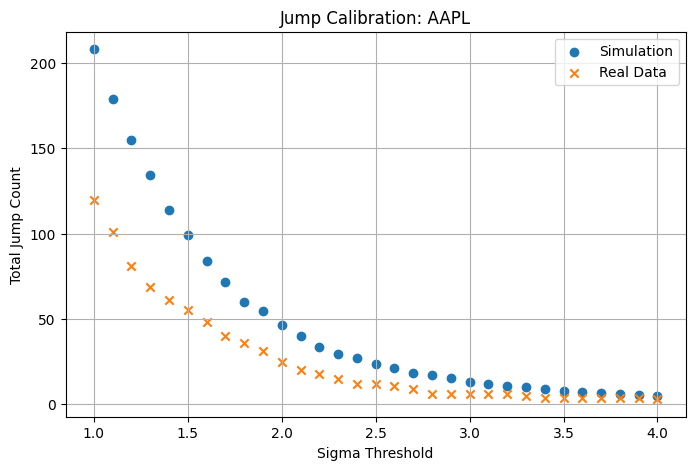

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


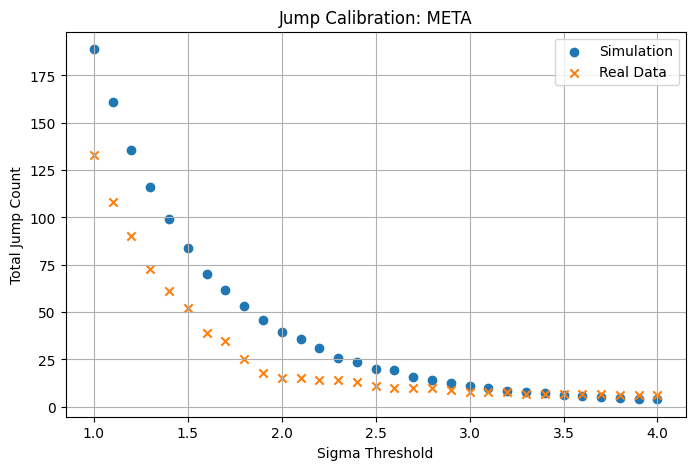

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


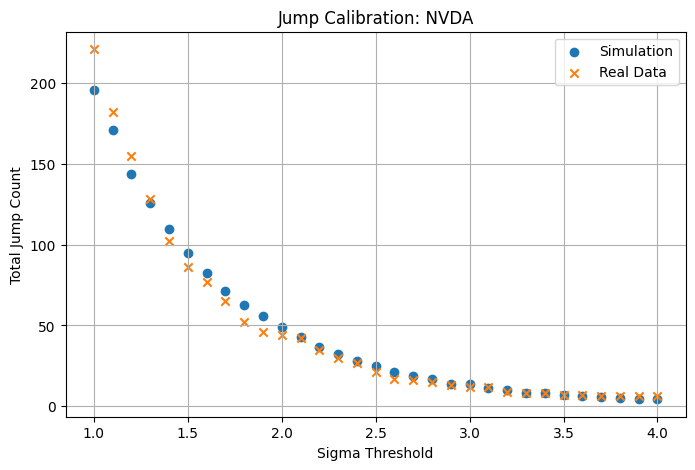

In [12]:
for name in test_stocks["big_tech_growth"]:
    jump_calibration_analysis(
        stock_name=name,
        training_start_date=training_start_date,
        evaluation_start_date=evaluation_start_date,
        evaluation_end_date=evaluation_end_date,
        montecarlo_days=montecarlo_days,
        montecarlo_iterations=montecarlo_iterations,
        jump_cutoff_range=(1, 4.1, 0.1),
        plot=True
    )

Now we save all the plots, including the other sectors, in a single pdf file. This has already been run and is currently saved as [Open calibration PDF](../outputs/jump_calibration_results_V1.pdf), or in ../outputs/jump_calibration_results_V1.pdf

In [ ]:
with PdfPages("../outputs/jump_calibration_results_V1.pdf") as pdf:

    for category, stock_list in test_stocks.items():

        for stock in stock_list:

            simulation_jumps, real_jumps = jump_calibration_analysis(
                stock_name=stock,
                training_start_date=training_start_date,
                evaluation_start_date=evaluation_start_date,
                evaluation_end_date=evaluation_end_date,
                montecarlo_days=montecarlo_days,
                montecarlo_iterations=montecarlo_iterations,
                jump_cutoff_range=jump_cutoff_range,
                plot=False
            )

            # Recreate plot here

            sigma_values = np.arange(
                jump_cutoff_range[0],
                jump_cutoff_range[1],
                jump_cutoff_range[2]
            )

            fig = plt.figure(figsize=(8,5))

            plt.scatter(
                sigma_values,
                simulation_jumps[stock],
                marker="o",
                label="Simulation"
            )

            plt.scatter(
                sigma_values,
                real_jumps[stock],
                marker="x",
                label="Real Data"
            )

            plt.title(f"{category} - {stock}")
            plt.xlabel("Sigma Threshold")
            plt.ylabel("Total Jump Count")
            plt.legend()
            plt.grid()

            pdf.savefig(fig)
            plt.close(fig)

The data shows clearly that for most stocks the simulation over fits jumps i.e. more jumps than the real data shows. Under primary inspection this seems to stem from a double consideration of the jumps, namely a jump may occur either from the manual jump inclusion in the simulation or form the gaussian selection of the stock change for the day.

In reality we now see that we only want the jumps to come from one source, with the better source being the manual jump inclusion. This addresses the tails of our gaussian manually. 

More evidence of this can be seen when running the (current version of the) simulation without jumps and still yielding a non 0 jump count.

The fix proposed is to limit the nominal movements of the stock to always be within the jump cutoff range and if it selects some tail reuslt it will be forced to re-select until it only contains non jump changes.

A sample of the resulting jump comparison can be seen below with a more comprehensive jump graph list available in [Open calibration optimized PDF](../outputs/jump_calibration_results_V2.pdf), or in ../outputs/jump_calibration_results_V2.pdf

In [5]:
simulation_jumps = {}
real_jumps = {}
with PdfPages("../outputs/jump_calibration_results_V2.pdf") as pdf:

    for category, stock_list in test_stocks.items():

        for stock in stock_list:

            simulation_jumps, real_jumps = jump_calibration_analysis(
                stock_name=stock,
                training_start_date=training_start_date,
                evaluation_start_date=evaluation_start_date,
                evaluation_end_date=evaluation_end_date,
                montecarlo_days=montecarlo_days,
                montecarlo_iterations=montecarlo_iterations,
                jump_cutoff_range=jump_cutoff_range,
                simulation_jumps=simulation_jumps,
                real_jumps=real_jumps,
                plot=False
            )

            # Recreate plot here

            sigma_values = np.arange(
                jump_cutoff_range[0],
                jump_cutoff_range[1],
                jump_cutoff_range[2]
            )

            fig = plt.figure(figsize=(8,5))

            plt.scatter(
                sigma_values,
                simulation_jumps[stock],
                marker="o",
                label="Simulation"
            )

            plt.scatter(
                sigma_values,
                real_jumps[stock],
                marker="x",
                label="Real Data"
            )

            plt.title(f"{category} - {stock}")
            plt.xlabel("Sigma Threshold")
            plt.ylabel("Total Jump Count")
            plt.legend()
            plt.grid()

            pdf.savefig(fig)
            plt.close(fig)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [11]:
simulation_jumps.keys()

dict_keys(['AAPL', 'META', 'NVDA', 'TSLA', 'AMD', 'NFLX', 'KO', 'PG', 'JNJ', 'JPM', 'GS', 'BAC', 'AMZN', 'WMT', 'COST', 'CAT', 'BA', 'GE', 'XOM', 'CVX', 'SLB'])

This now much closer represents the real data as hoped. However, there is still a discrepancy. to see if this discrepancy can be globally approximated an exponential decay curve is fit to all the data points. the resulting factor are all compared to the actual curve and their ratio is taken to determine is there is some unifying correlation which we can exploit to improve the simulation further.

In [11]:
#defining our fit function, it looks a bit like an exponential decay so lets try that
def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

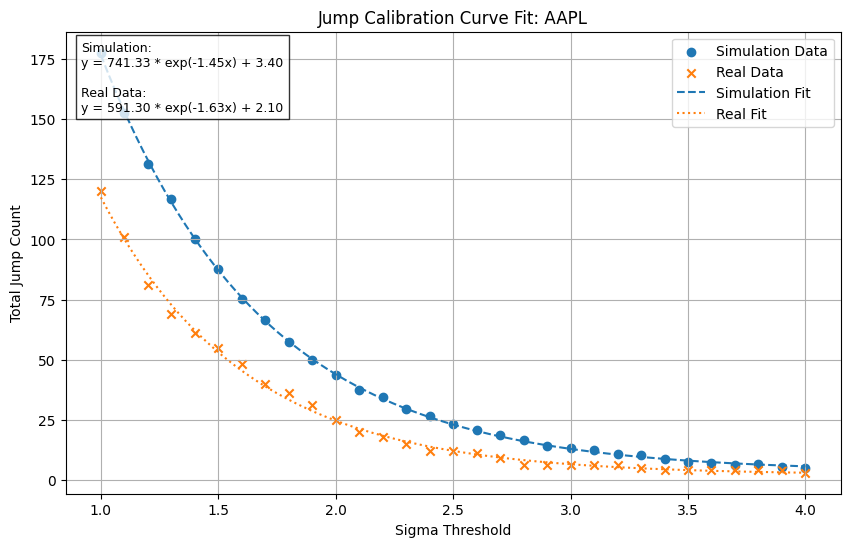

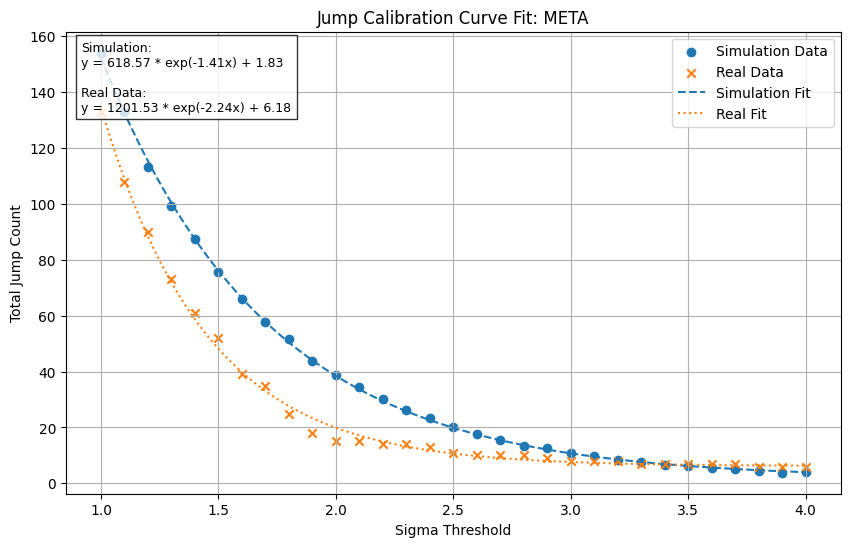

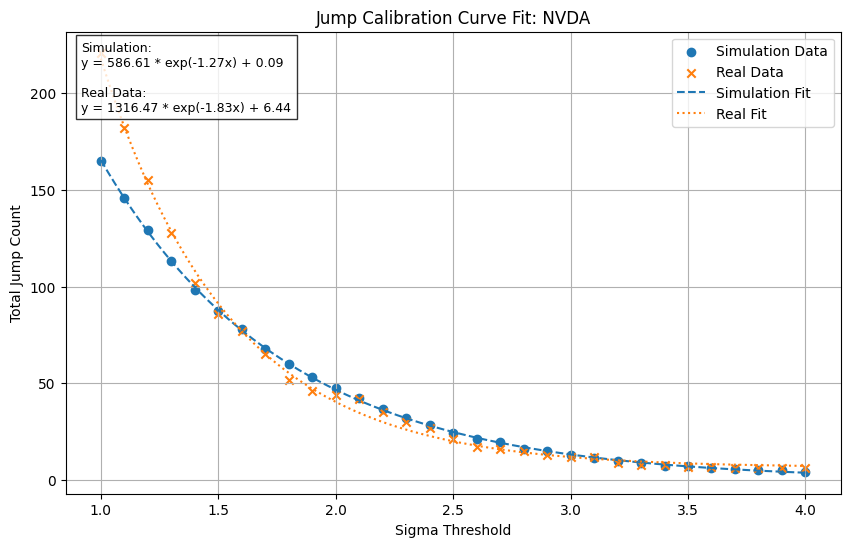

In [ ]:
#since we already generated and have all the data above we dont have to redownload and run everything, instead we use the data produced by the jump calibration analysis function directly.

with PdfPages("../outputs/jump_calibration_results_V2_fit.pdf") as pdf:
    #adding a quick factor to not show all graphs but save all to the pdf instead
    i = 0

    #dictionaries which we will append to for both simulation and actual data
    simulation_fit_parameters = {}
    real_fit_parameters = {}
    for category, stock_list in test_stocks.items():

        for stock in stock_list:

            # Recreate plot here
            sigma_values = np.arange(
                jump_cutoff_range[0],
                jump_cutoff_range[1],
                jump_cutoff_range[2]
            )

            #reading in our data generated in the previous cell

            sim_y = np.array(simulation_jumps[stock])
            real_y = np.array(real_jumps[stock])
            x = sigma_values[:len(sim_y)]

            #and fitting the exponential decay to both. 
            sim_params, _ = curve_fit(
            exponential_decay,
            x,
            sim_y,
             p0=[max(sim_y), 1.0, min(sim_y)],
            maxfev=10000
            )

            real_params, _ = curve_fit(
            exponential_decay,
            x,
            real_y,
             p0=[max(real_y), 1.0, min(real_y)],
            maxfev=10000
            )

            # Store fit parameters

            simulation_fit_parameters[stock] = {

                "a": sim_params[0],
                "b": sim_params[1],
                "c": sim_params[2]

            }

            real_fit_parameters[stock] = {

                "a": real_params[0],
                "b": real_params[1],
                "c": real_params[2]

            }


            # Generate smooth fitted curves

            x_smooth = np.linspace(
                x.min(),
                x.max(),
                300
            )

            sim_fit = exponential_decay(
                x_smooth,
                *sim_params
            )

            real_fit = exponential_decay(
                x_smooth,
                *real_params
            )


            # Equation strings

            sim_eq = (
                f"Simulation:\n"
                f"y = {sim_params[0]:.2f}"
                f" * exp(-{sim_params[1]:.2f}x)"
                f" + {sim_params[2]:.2f}"
            )

            real_eq = (
                f"Real Data:\n"
                f"y = {real_params[0]:.2f}"
                f" * exp(-{real_params[1]:.2f}x)"
                f" + {real_params[2]:.2f}"
            )

            # Plot
            plt.figure(figsize=(10, 6))

            # Raw data
            plt.scatter(
                x,
                sim_y,
                label="Simulation Data",
                marker="o"
            )

            plt.scatter(
                x,
                real_y,
                label="Real Data",
                marker="x"
            )

            # Fitted curves
            plt.plot(
                x_smooth,
                sim_fit,
                linestyle="--",
                label="Simulation Fit"
            )

            plt.plot(
                x_smooth,
                real_fit,
                linestyle=":",
                label="Real Fit"
            )

            # Labels
            plt.title(f"Jump Calibration Curve Fit: {stock}")

            plt.xlabel("Sigma Threshold")

            plt.ylabel("Total Jump Count")

            plt.grid()

            plt.legend()

            # Put equations on graph
            plt.text(
                0.02,
                0.98,
                sim_eq + "\n\n" + real_eq,
                transform=plt.gca().transAxes,
                fontsize=9,
                verticalalignment="top",
                bbox=dict(
                    facecolor="white",
                    alpha=0.8
                )
            )

            # Save page to PDF
            pdf.savefig()
            if i < 3:
                plt.show()
            i += 1
            
            plt.close()

We observe that an exponential decay models the jump-count curves reasonably well for both the simulated and real market data. To investigate whether a global relationship exists between the simulation and real-data behavior, the ratios between corresponding fit parameters are computed for each stock. These ratios are then averaged across all assets, with the standard deviation used as a measure of the consistency and variability of the calibration relationship.

In [7]:
simulation_fit_parameters.keys()

dict_keys(['AAPL', 'META', 'NVDA', 'TSLA', 'AMD', 'NFLX', 'KO', 'PG', 'JNJ', 'JPM', 'GS', 'BAC', 'AMZN', 'WMT', 'COST', 'CAT', 'BA', 'GE', 'XOM', 'CVX', 'SLB'])

In [8]:
a_ratio = []
b_ratio = []
c_ratio = []
for category, stock_list in test_stocks.items():
        for stock in stock_list:
            a_ratio.append(real_fit_parameters[stock]["a"] / simulation_fit_parameters[stock]["a"])
            b_ratio.append(real_fit_parameters[stock]["b"] / simulation_fit_parameters[stock]["b"])
            c_ratio.append(real_fit_parameters[stock]["c"] / simulation_fit_parameters[stock]["c"])

In [9]:
print(f"amplitude factor: {np.mean(a_ratio):.4f} ± {np.std(a_ratio):.4f}")
print(f"decay rate: {np.mean(b_ratio):.4f} ± {np.std(b_ratio):.4f}")
print(f"phase shift: {np.mean(c_ratio):.4f} ± {np.std(c_ratio):.4f}")

amplitude factor: 1.5074 ± 0.5042
decay rate: 1.3887 ± 0.1965
phase shift: 4.5099 ± 14.2013


We can see from the ratio results that the amplitude and phase shift factors are very irregular with no significant global correlation. However, the decay rate does seem to be within a about 15% range between stocks from different sector and sizes. this would suggest that our simulation on average still permits too many jumps where we expect that with a larger sd factor the jumps permitted are fewer.

Since this does seem to correlate well the simulation can be adjusted by just this factor. We do this and call it version 3 outlined in the simulation code where we simply multiply the jump cut off point by 1.38. this should in turn translate to the desired change here.

Rerunning the same as above we now get

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


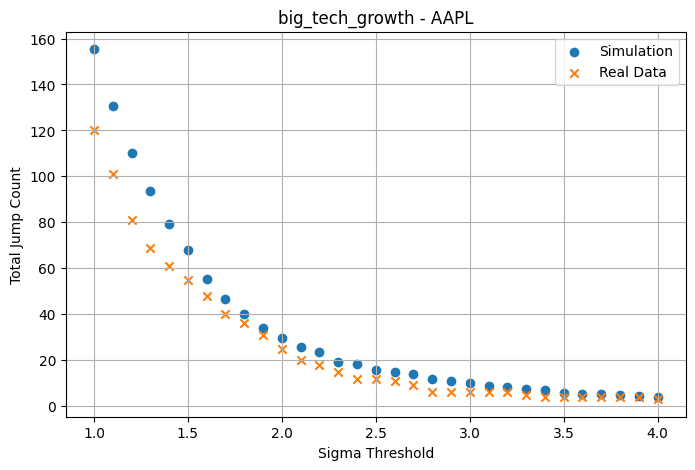

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


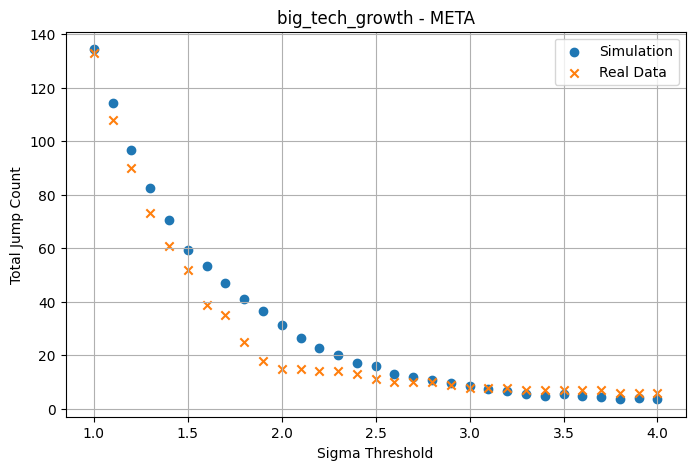

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


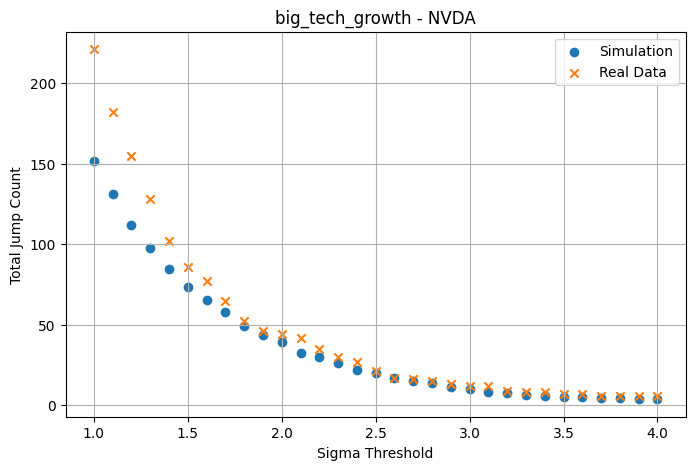

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [10]:
simulation_jumps={}
real_jumps={}

with PdfPages("../outputs/jump_calibration_results_V3.pdf") as pdf:
    i = 0
    for category, stock_list in test_stocks.items():

        for stock in stock_list:

            simulation_jumps, real_jumps = jump_calibration_analysis(
                stock_name=stock,
                training_start_date=training_start_date,
                evaluation_start_date=evaluation_start_date,
                evaluation_end_date=evaluation_end_date,
                montecarlo_days=montecarlo_days,
                montecarlo_iterations=montecarlo_iterations,
                jump_cutoff_range=jump_cutoff_range,
                simulation_jumps=simulation_jumps,
                real_jumps=real_jumps,
                plot=False
            )

            # Recreate plot here

            sigma_values = np.arange(
                jump_cutoff_range[0],
                jump_cutoff_range[1],
                jump_cutoff_range[2]
            )

            fig = plt.figure(figsize=(8,5))

            plt.scatter(
                sigma_values,
                simulation_jumps[stock],
                marker="o",
                label="Simulation"
            )

            plt.scatter(
                sigma_values,
                real_jumps[stock],
                marker="x",
                label="Real Data"
            )

            plt.title(f"{category} - {stock}")
            plt.xlabel("Sigma Threshold")
            plt.ylabel("Total Jump Count")
            plt.legend()
            plt.grid()

            pdf.savefig(fig)
            if(i < 3):
                plt.show()
            i += 1
            plt.close(fig)

To characterize if this is change is an improvement we fit the data again as before and take the ratio between the real and simulated data parameters. If the b parameter is closer to 1 we can qualitatively say to have improved the jump accuracy and hence the model accuracy. 

In [ ]:
#since we already generated and have all the data above we dont have to redownload and run everything, instead we use the data produced by the jump calibration analysis function directly.

#adding a quick factor to not show all graphs but save all to the pdf instead
i = 0

#dictionaries which we will append to for both simulation and actual data
simulation_fit_parameters = {}
real_fit_parameters = {}
for category, stock_list in test_stocks.items():

    for stock in stock_list:

        # Recreate plot here
        sigma_values = np.arange(
            jump_cutoff_range[0],
            jump_cutoff_range[1],
            jump_cutoff_range[2]
        )

        #reading in our data generated in the previous cell

        sim_y = np.array(simulation_jumps[stock])
        real_y = np.array(real_jumps[stock])
        x = sigma_values[:len(sim_y)]

        #and fitting the exponential decay to both. 
        sim_params, _ = curve_fit(
        exponential_decay,
        x,
        sim_y,
            p0=[max(sim_y), 1.0, min(sim_y)],
        maxfev=10000
        )

        real_params, _ = curve_fit(
        exponential_decay,
        x,
        real_y,
            p0=[max(real_y), 1.0, min(real_y)],
        maxfev=10000
        )

        # Store fit parameters

        simulation_fit_parameters[stock] = {

            "a": sim_params[0],
            "b": sim_params[1],
            "c": sim_params[2]

        }

        real_fit_parameters[stock] = {

            "a": real_params[0],
            "b": real_params[1],
            "c": real_params[2]

        }


a_ratio = []
b_ratio = []
c_ratio = []
for category, stock_list in test_stocks.items():
        for stock in stock_list:
            a_ratio.append(real_fit_parameters[stock]["a"] / simulation_fit_parameters[stock]["a"])
            b_ratio.append(real_fit_parameters[stock]["b"] / simulation_fit_parameters[stock]["b"])
            c_ratio.append(real_fit_parameters[stock]["c"] / simulation_fit_parameters[stock]["c"])

print(f"amplitude factor: {np.mean(a_ratio):.4f} ± {np.std(a_ratio):.4f}")
print(f"decay rate: {np.mean(b_ratio):.4f} ± {np.std(b_ratio):.4f}")
print(f"phase shift: {np.mean(c_ratio):.4f} ± {np.std(c_ratio):.4f}")


amplitude factor: 1.4116 ± 0.5320
decay rate: 1.2154 ± 0.2292
phase shift: 1.1836 ± 0.9769


And now, we can see that the decay rate is indeed closer to 1 as intended but importantly without significantly changing the SD. The phase shift and amplitude factors also moved closer to 1 meaning the data and simulations more closely align in general. Therefore the correction factor added in as V3 will remain in place.